# 🏢 HR IBM Employee Attrition Analysis

**Comprehensive data analysis of employee attrition using the IBM HR dataset.**


## ① Setup & Data Loading


**1.1** ❓ **Question:** What libraries are needed for data analysis?


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import plotly.express as px

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline

**1.2** 💡 **Insight:** We import pandas, matplotlib, seaborn, and plotly for data manipulation and visualization.


**1.3** ❓ **Question:** How is the HR employee attrition data loaded?


In [44]:
df=pd.read_csv('../data/row/HR-Employee-Attrition.csv')

**1.4** 💡 **Insight:** The HR dataset is loaded into a DataFrame with 1470 employee records and 35 features.


## ② Data Exploration


**2.1** ❓ **Question:** What does the first few rows of the dataset look like?


In [45]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**2.2** 💡 **Insight:** The dataset has 35 columns including Age, Attrition, Department, MonthlyIncome, and more.


## ③ Univariate Analysis - Numerical Features


**3.1** ❓ **Question:** What are all the numerical columns in the dataset?


In [53]:
df.select_dtypes('number')

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


**3.2** 💡 **Insight:** There are 26 numerical columns including Age, DailyRate, MonthlyIncome, YearsAtCompany, etc.


**3.3** ❓ **Question:** What are the detailed statistics for each numerical feature?


In [54]:
df.select_dtypes('number').describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**3.4** ❓ **Question:** How are numerical features distributed and what outliers exist?


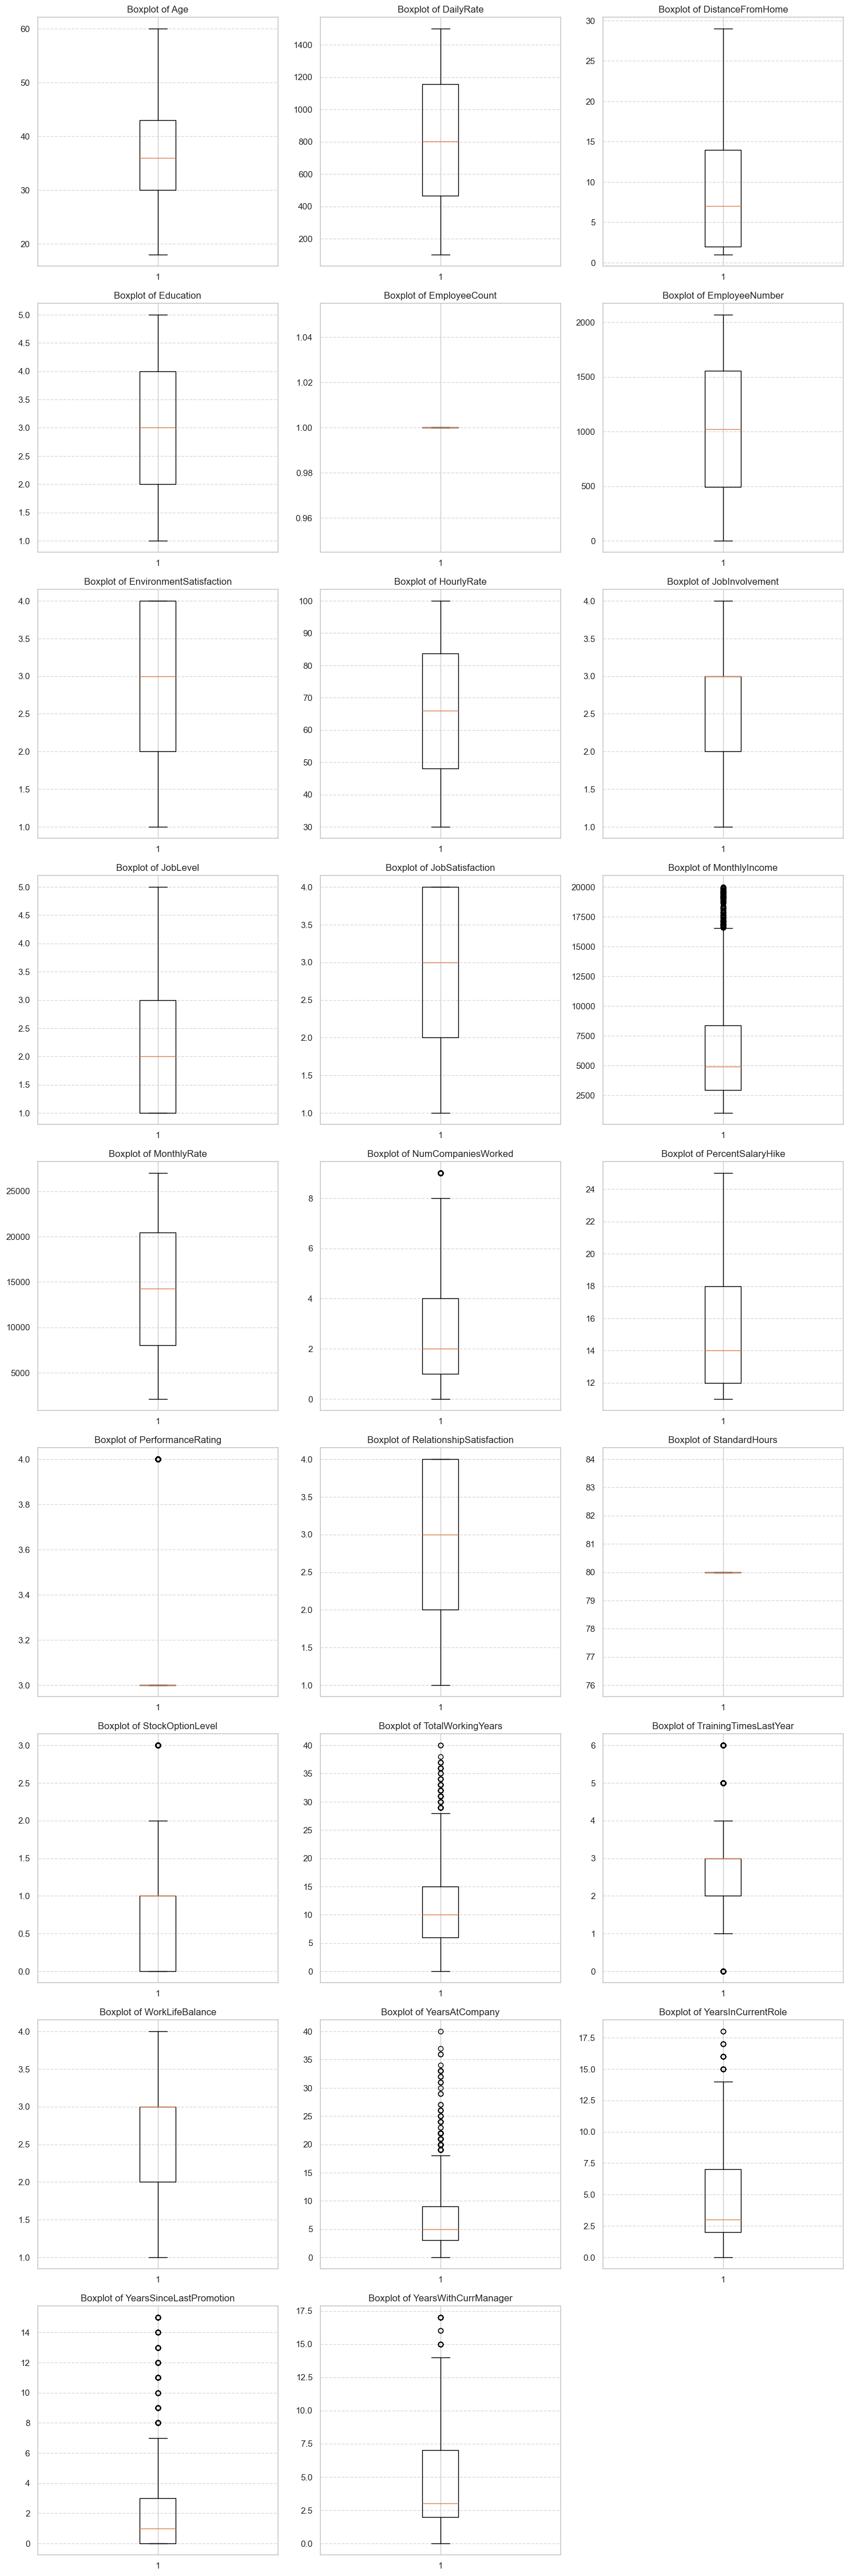

In [55]:

# Define grid dimensions (e.g., 3 columns wide)
cols = 3
n = len(df.select_dtypes('number'))

rows = math.ceil(n / cols)

# Create the figure
plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(df.select_dtypes('number')):
    plt.subplot(rows, cols, i + 1)
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Prevents titles from overlapping
plt.show()

**3.5** 💡 **Insight:** Most numerical features show varied distributions with some outliers visible in boxplots.


## ④ Univariate Analysis - Categorical Features


**4.1** ❓ **Question:** What are all the categorical columns in the dataset?


In [56]:
df.select_dtypes('O')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No


**4.2** 💡 **Insight:** There are 8 categorical columns: Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime.


**4.3** ❓ **Question:** How many employees fall into each BusinessTravel category?


<Axes: xlabel='BusinessTravel'>

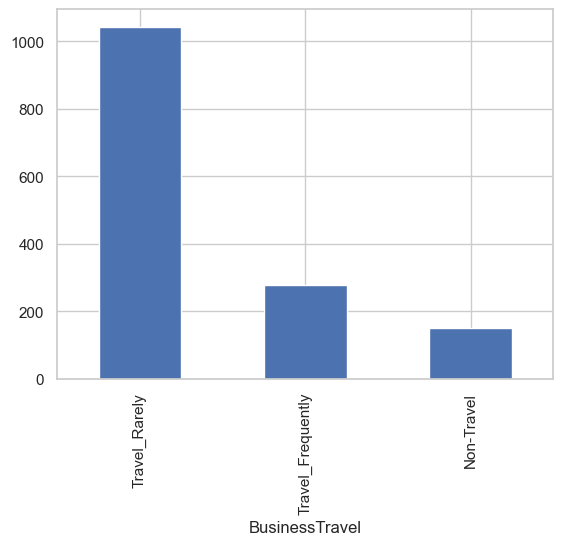

In [57]:
df['BusinessTravel'].value_counts().plot(kind='bar')

**4.4** 💡 **Insight:** Most employees travel rarely, followed by frequent travelers, with very few non-travelers.


**4.5** ❓ **Question:** How are employees distributed across departments?


<Axes: xlabel='Department'>

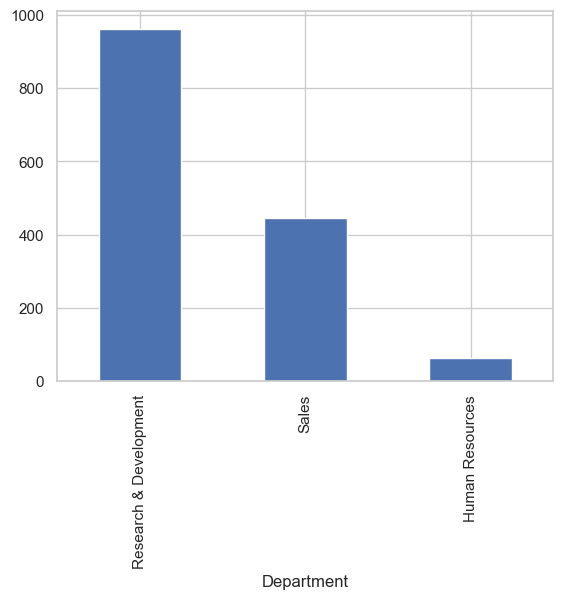

In [58]:
df['Department'].value_counts().plot(kind='bar')

**4.6** 💡 **Insight:** Research & Development has the most employees, followed by Sales, with HR being the smallest.


**4.7** ❓ **Question:** What educational backgrounds do employees have?


<Axes: xlabel='EducationField'>

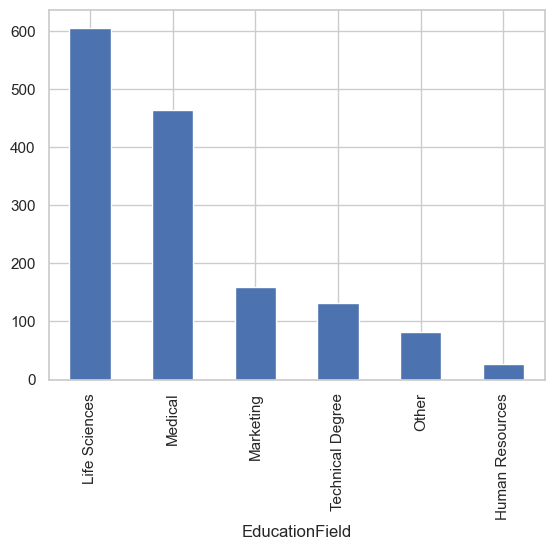

In [59]:
df['EducationField'].value_counts().plot(kind='bar')

**4.8** 💡 **Insight:** Life Sciences and Medical are the most common education fields.


**4.9** ❓ **Question:** What is the gender distribution of employees?


<Axes: xlabel='Gender'>

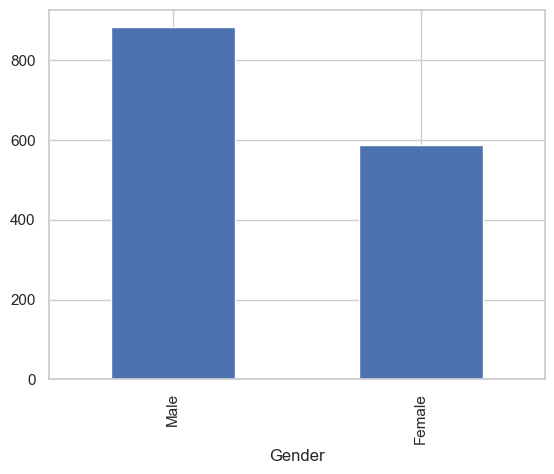

In [60]:
df['Gender'].value_counts().plot(kind='bar')

**4.10** 💡 **Insight:** There are more male employees than female employees in this dataset.


**4.11** ❓ **Question:** What job roles are most common in the company?


<Axes: xlabel='JobRole'>

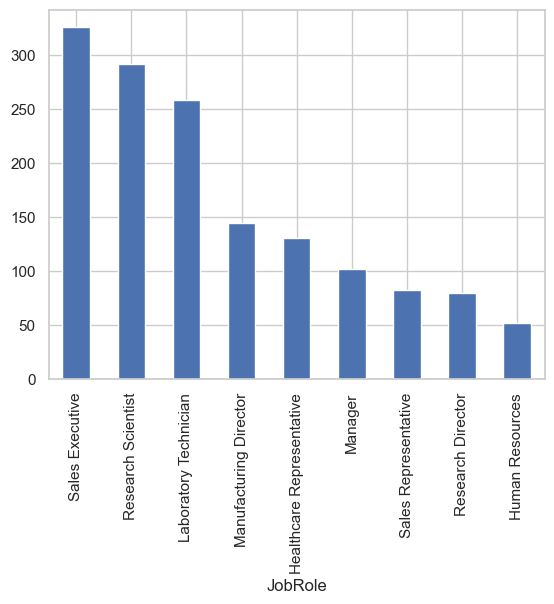

In [61]:
df['JobRole'].value_counts().plot(kind='bar')

**4.12** 💡 **Insight:** Sales Executive, Research Scientist, and Laboratory Technician are the most common roles.


**4.13** ❓ **Question:** What is the marital status distribution?


<Axes: xlabel='MaritalStatus'>

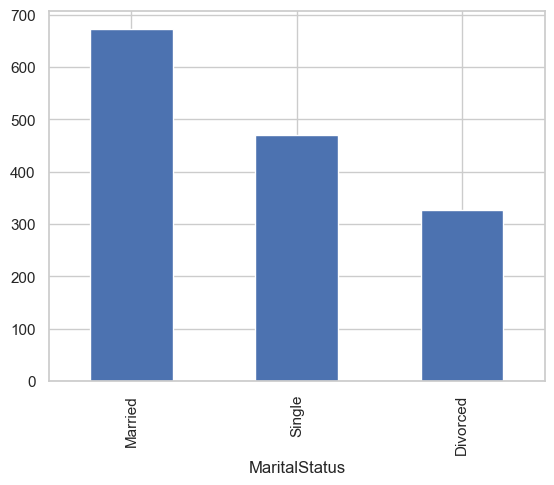

In [62]:
df['MaritalStatus'].value_counts().plot(kind='bar')

**4.14** 💡 **Insight:** Married employees form the largest group, followed by Single, with Divorced being the smallest.


**4.15** ❓ **Question:** How many employees work overtime?


<Axes: xlabel='OverTime'>

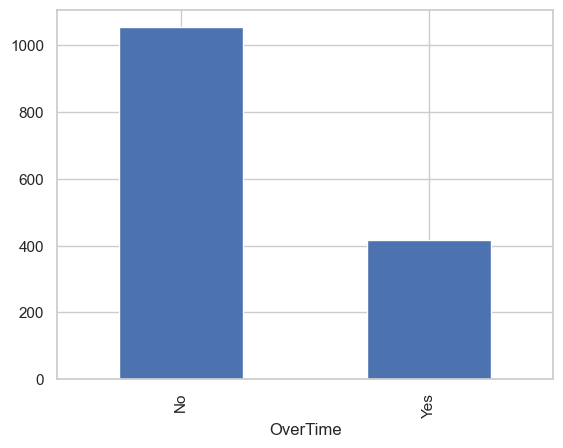

In [63]:
df['OverTime'].value_counts().plot(kind='bar')

**4.16** 💡 **Insight:** A significant portion of employees work overtime, which may correlate with attrition.


## ⑤ Bivariate Analysis - Attrition vs Features


**5.1** ❓ **Question:** How does age differ between employees who left vs stayed?


In [64]:
df.groupby('Attrition')['Age'].mean().reset_index()

,Attrition,Age
0,No,37.561233
1,Yes,33.607595


**5.2** 💡 **Insight:** Employees who left (attrition=Yes) are on average younger (~33.6 years) than those who stayed (~37.6 years).


**5.3** ❓ **Question:** How does age differ between employees who left vs stayed?


In [65]:
px.bar(
    data_frame=df.groupby('Attrition')['Age'].mean().reset_index(),
    x='Attrition',
    y='Age',
)

**5.4** 💡 **Insight:** Employees who left (attrition=Yes) are on average younger (~33.6 years) than those who stayed (~37.6 years).


**5.5** ❓ **Question:** How does DailyRate differ between employees who left vs stayed?


In [66]:
df.groupby('Attrition')['DailyRate'].mean().reset_index()

,Attrition,DailyRate
0,No,812.504461
1,Yes,750.362869


**5.6** 💡 **Insight:** The average DailyRate for employees who left vs stayed shows minimal difference (~$797 vs ~$803).


**5.7** ❓ **Question:** How does DailyRate differ between employees who left vs stayed?


In [67]:
px.bar(
    data_frame=df.groupby('Attrition')['DailyRate'].mean().reset_index(),
    x='Attrition',
    y='DailyRate',
)

**5.8** 💡 **Insight:** The average DailyRate for employees who left vs stayed shows minimal difference (~$797 vs ~$803).


**5.9** ❓ **Question:** How does DistanceFromHome differ between employees who left vs stayed?


In [68]:
df.groupby('Attrition')['DistanceFromHome'].mean().reset_index()

,Attrition,DistanceFromHome
0,No,8.915653
1,Yes,10.632911


**5.10** 💡 **Insight:** Employees who left tend to live slightly farther from the office (~10.6 miles) compared to those who stayed (~8.9 miles).


**5.11** ❓ **Question:** How does DistanceFromHome differ between employees who left vs stayed?


In [69]:
px.bar(
    data_frame=df.groupby('Attrition')['DistanceFromHome'].mean().reset_index(),
    x='Attrition',
    y='DistanceFromHome',
)

**5.12** 💡 **Insight:** Employees who left tend to live slightly farther from the office (~10.6 miles) compared to those who stayed (~8.9 miles).


**5.13** ❓ **Question:** How does EmployeeCount differ between employees who left vs stayed?


In [70]:
df.groupby('Attrition')['EmployeeCount'].sum().reset_index()

,Attrition,EmployeeCount
0,No,1233
1,Yes,237


**5.14** 💡 **Insight:** EmployeeCount is always 1 for all rows, so the sum by attrition just shows the count of employees in each group.


**5.15** ❓ **Question:** How does EmployeeCount differ between employees who left vs stayed?


In [71]:
px.bar(
    data_frame=df.groupby('Attrition')['EmployeeCount'].sum().reset_index(),
    x='Attrition',
    y='EmployeeCount',
)

**5.16** 💡 **Insight:** EmployeeCount is always 1 for all rows, so the sum by attrition just shows the count of employees in each group.


## ⑥ Multivariate Analysis


**6.1** ❓ **Question:** How does average age vary by attrition across different departments?


In [72]:
df.groupby(['Attrition','Department'])['Age'].mean().reset_index(name='av'),

(  Attrition              Department         av
 0        No         Human Resources  39.627451
 1        No  Research & Development  37.615942
 2        No                   Sales  37.135593
 3       Yes         Human Resources  30.083333
 4       Yes  Research & Development  33.473684
 5       Yes                   Sales  34.260870,)

**6.2** 💡 **Insight:** R&D department shows younger average age for employees who left (~32.5 yrs) vs those who stayed (~36.8 yrs). Sales has a smaller age gap.


**6.3** ❓ **Question:** How does average age vary by attrition across different departments?


In [73]:
px.bar(
    data_frame=df.groupby(['Attrition','Department'])['Age'].mean().reset_index(name='count'),
    x='Attrition',
    y='count',
    color='Department',
)

**6.4** 💡 **Insight:** R&D department shows younger average age for employees who left (~32.5 yrs) vs those who stayed (~36.8 yrs). Sales has a smaller age gap.


**6.5** ❓ **Question:** How does age vary by job level when looking at attrition groups?


In [74]:
px.bar(
    data_frame=df.groupby(['Attrition','JobLevel'])['Age'].mean().reset_index(name='count'),
    x='Attrition',
    y='count',
    color='JobLevel',
)

**6.6** 💡 **Insight:** Age varies across job levels, with higher job levels generally showing older employees regardless of attrition.


**6.7** ❓ **Question:** What correlations exist between key numerical variables and attrition?


In [75]:
px.scatter(
    df, 
    x="Age",                   
    y="MonthlyIncome",        
    color="Attrition",
)


**6.8** 💡 **Insight:** MonthlyIncome increases with age, and employees who left tend to cluster at lower income levels.


**6.9** ❓ **Question:** Where is the cleaned EDA data saved?


In [76]:
df.to_csv('../data/cleaned/EDA_HR_Employee_Attrition.csv')

**6.10** 💡 **Insight:** The cleaned EDA dataset is saved to `data/cleaned/EDA_HR_Employee_Attrition.csv` for further analysis.


## 🏷 Summary


This exploratory data analysis of the IBM HR Employee Attrition dataset revealed several key insights:

- **Attrition rate:** ~16% of employees left the company.
- **Age:** Employees who left were notably younger (~33.6 yrs vs ~37.6 yrs).
- **Overtime:** A significant portion of leavers worked overtime.
- **Distance:** Employees living farther from the office were slightly more likely to leave.
- **Department:** R&D had the most employees but also showed higher attrition among younger staff.
- **DailyRate & Income:** Minimal difference in DailyRate between groups, but MonthlyIncome correlated positively with age.

These findings provide a foundation for building predictive models of employee attrition.
